<a href="https://colab.research.google.com/github/aryalankit121/CIS-3400-Advanced-Programming/blob/main/Copy_of_CIS3400_Week7_Monday_Guided_EDA_BTS_June2026_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIS 3400 Advanced Programming — Week 7
## Exploring & Visualizing Real Data with Python
### U.S. Airline On-Time Performance — June 2026

**Name:** Ankit Aryal   
**Date:** September 28, 2026

---

## Today's Goal

Today we will use **real U.S. airline flight records** to follow a complete Exploratory Data Analysis (EDA) workflow.

Our overall question is:

> **What can June 2026 flight data tell airline and airport managers about delays and operational patterns?**

We will work through:

**Question → Inspect → Clean → Transform → Group/Aggregate → Visualize → Interpret → Communicate**

### Individual Submission

Follow along during class, run the code, and complete every **STOP & ANSWER** section in your own words.

You will submit this completed notebook individually in Blackboard.

### AI / VIBE Coding

AI may help you understand code, debug, or explore an idea. However, **you are responsible for understanding the code and interpreting the results.**


# 1. Import Our Python Libraries

We will use:

- **pandas** — working with tables/DataFrames
- **matplotlib** — creating visualizations


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 70)


# 2. Load the Real BTS Flight Data

Upload the June 2026 BTS CSV to Colab, or place it in the same folder as this notebook if using Jupyter/VS Code.

Change the filename below **only if your downloaded file has a different name**.


In [4]:
FILE = "airline_ontime_2026.csv"

df = pd.read_csv(FILE, low_memory=False)

print("Data loaded!")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")


Data loaded!
Rows: 607,577
Columns: 64


## STOP & ANSWER 1 — Before We Analyze

A row in this dataset represents one scheduled flight.

Before looking closely at the results, what is **one pattern** you expect we might find in airline delays?

**Your prediction:**  
Delays due to weather would be significant in number.


# 3. Inspect Before You Analyze


In [5]:
display(df.head())


,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,ORIGIN_STATE_FIPS,ORIGIN_STATE_NM,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_FIPS,DEST_STATE_NM,DEST_WAC,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,DEP_DELAY_GROUP,DEP_TIME_BLK,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,ARR_DELAY_GROUP,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME,LONGEST_ADD_GTIME
0,2026,2,6,1,1,6/1/2026 0:00,AA,19805,AA,N101NN,171,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,12892,1289209,32575,LAX,"Los Angeles, CA",CA,6,California,91,600,553.0,-7.0,0.0,0.0,-1.0,0600-0659,18.0,611.0,854.0,10.0,915,904.0,-11.0,0.0,0.0,-1.0,0900-0959,0,NaN,0,375.0,371.0,343.0,1,2475,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026,2,6,1,1,6/1/2026 0:00,AA,19805,AA,N101NN,177,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,14771,1477104,32457,SFO,"San Francisco, CA",CA,6,California,91,2030,2023.0,-7.0,0.0,0.0,-1.0,2000-2059,32.0,2055.0,14.0,7.0,2359,21.0,22.0,22.0,1.0,1.0,2300-2359,0,NaN,0,389.0,418.0,379.0,1,2586,11,0.0,0.0,22.0,0.0,0.0,NaN,NaN,NaN
2,2026,2,6,1,1,6/1/2026 0:00,AA,19805,AA,N101NN,238,12892,1289209,32575,LAX,"Los Angeles, CA",CA,6,California,91,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,1010,1002.0,-8.0,0.0,0.0,-1.0,1000-1059,16.0,1018.0,1809.0,14.0,1843,1823.0,-20.0,0.0,0.0,-2.0,1800-1859,0,NaN,0,333.0,321.0,291.0,1,2475,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026,2,6,1,1,6/1/2026 0:00,AA,19805,AA,N102NN,10,12892,1289209,32575,LAX,"Los Angeles, CA",CA,6,California,91,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,2154,2152.0,-2.0,0.0,0.0,-1.0,2100-2159,14.0,2206.0,612.0,5.0,620,617.0,-3.0,0.0,0.0,-1.0,0600-0659,0,NaN,0,326.0,325.0,306.0,1,2475,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,2,6,1,1,6/1/2026 0:00,AA,19805,AA,N102NN,2,12892,1289209,32575,LAX,"Los Angeles, CA",CA,6,California,91,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,700,711.0,11.0,11.0,0.0,0.0,0700-0759,17.0,728.0,1520.0,7.0,1530,1527.0,-3.0,0.0,0.0,-1.0,1500-1559,0,NaN,0,330.0,316.0,292.0,1,2475,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Dataset shape: (607577, 64)

Column names:
['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_FIPS', 'ORIGIN_STATE_NM', 'ORIGIN_WAC', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEST_STATE_FIPS', 'DEST_STATE_NM', 'DEST_WAC', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15', 'DEP_DELAY_GROUP', 'DEP_TIME_BLK', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15', 'ARR_DELAY_GROUP', 'ARR_TIME_BLK', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS', 'DISTANCE', 'DISTANCE_GROUP', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607577 entries, 0 to 607576
Data columns (total 64 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   YEAR                   607577 non-null  int64  
 1   QUARTER                607577 non-null  int64  
 2   MONTH                  607577 non-null  int64  
 3   DAY_OF_MONTH           607577 non-null  int64  
 4   DAY_OF_WEEK            607577 non-null  int64  
 5   FL_DATE                607577 non-null  object 
 6   OP_UNIQUE_CARRIER      607577 non-null  object 
 7   OP_CARRIER_AIRLINE_ID  607577 non-null  int64  
 8   OP_CARRIER             607577 non-null  object 
 9   TAIL_NUM               606745 non-null  object 
 10  OP_CARRIER_FL_NUM      607577 non-null  int64  
 11  ORIGIN_AIRPORT_ID      607577 non-null  int64  
 12  ORIGIN_AIRPORT_SEQ_ID  607577 non-null  int64  
 13  ORIGIN_CITY_MARKET_ID  607577 non-null  int64  
 14  ORIGIN                 607577 non-nu

## STOP & ANSWER 2 — Know Your Data

1. How many rows are in the dataset?  
2. How many columns?  
3. Name **three columns** you think will be useful for understanding delays.  
4. Identify one column whose meaning you would need to investigate before using it.

**Your answers:**  
1. 607577 Rows
2. 64 Columns
3. Three columns: WEATHER_DELAY, ARR_DELAY, DEP_DELAY
4. ORIGIN_WAC


# 4. Select the Columns We Need

The original government dataset contains many fields. We do **not** need every field for every question.

Selecting useful columns makes our analysis easier to read and understand.

Notice: we keep the original `df` and create a smaller DataFrame called `flights`.


In [26]:
useful_columns = [
    "FL_DATE",
    "DAY_OF_WEEK",
    "OP_CARRIER",
    "OP_CARRIER_FL_NUM",
    "ORIGIN",
    "ORIGIN_CITY_NAME",
    "DEST",
    "DEST_CITY_NAME",
    "CRS_DEP_TIME",
    "DEP_TIME",
    "DEP_DELAY",
    "DEP_DEL15",
    "DEP_TIME_BLK",
    "CRS_ARR_TIME",
    "ARR_TIME",
    "ARR_DELAY",
    "ARR_DEL15",
    "ARR_TIME_BLK",
    "CANCELLED",
    "CANCELLATION_CODE",
    "DIVERTED",
    "CRS_ELAPSED_TIME",
    "AIR_TIME",
    "DISTANCE",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

flights = df[useful_columns].copy()

print("Original shape:", df.shape)
print("Working shape:", flights.shape)
display(flights.head())

Original shape: (607577, 64)
Working shape: (607577, 29)


,FL_DATE,DAY_OF_WEEK,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DEL15,DEP_TIME_BLK,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DEL15,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,6/1/2026 0:00,1,AA,171,JFK,"New York, NY",LAX,"Los Angeles, CA",600,553.0,-7.0,0.0,0600-0659,915,904.0,-11.0,0.0,0900-0959,0,NaN,0,375.0,343.0,2475,NaN,NaN,NaN,NaN,NaN
1,6/1/2026 0:00,1,AA,177,JFK,"New York, NY",SFO,"San Francisco, CA",2030,2023.0,-7.0,0.0,2000-2059,2359,21.0,22.0,1.0,2300-2359,0,NaN,0,389.0,379.0,2586,0.0,0.0,22.0,0.0,0.0
2,6/1/2026 0:00,1,AA,238,LAX,"Los Angeles, CA",JFK,"New York, NY",1010,1002.0,-8.0,0.0,1000-1059,1843,1823.0,-20.0,0.0,1800-1859,0,NaN,0,333.0,291.0,2475,NaN,NaN,NaN,NaN,NaN
3,6/1/2026 0:00,1,AA,10,LAX,"Los Angeles, CA",JFK,"New York, NY",2154,2152.0,-2.0,0.0,2100-2159,620,617.0,-3.0,0.0,0600-0659,0,NaN,0,326.0,306.0,2475,NaN,NaN,NaN,NaN,NaN
4,6/1/2026 0:00,1,AA,2,LAX,"Los Angeles, CA",JFK,"New York, NY",700,711.0,11.0,0.0,0700-0759,1530,1527.0,-3.0,0.0,1500-1559,0,NaN,0,330.0,292.0,2475,NaN,NaN,NaN,NaN,NaN


## STOP & ANSWER 3 — Why Make a Smaller DataFrame?

Why might it be useful to create `flights` instead of deleting unwanted columns from `df`?

**Your answer:**  
Creating a smaller DataFrame (flights) keeps the original df intact as an untouched source of truth. This allows us to access omitted columns later without reloading the full dataset from disk. Additionally, it avoids notebook state errors (KeyError) when re-running cells out of order, while keeping our workspace clean and focused specifically on delay analysis.


# 5. Data Quality: Missing Values


In [9]:
missing = flights.isna().sum().sort_values(ascending=False)

display(
    pd.DataFrame({
        "Missing": missing,
        "Percent Missing": (missing / len(flights) * 100).round(1)
    }).head(15)
)


,Missing,Percent Missing
CANCELLATION_CODE,597558,98.4
LATE_AIRCRAFT_DELAY,454540,74.8
NAS_DELAY,454540,74.8
SECURITY_DELAY,454540,74.8
CARRIER_DELAY,454540,74.8
WEATHER_DELAY,454540,74.8
ARR_DELAY,12382,2.0
ARR_DEL15,12382,2.0
AIR_TIME,12382,2.0
ARR_TIME,10340,1.7


### Missing does NOT automatically mean bad data

Look at the delay-cause columns:

- `CARRIER_DELAY`
- `WEATHER_DELAY`
- `NAS_DELAY`
- `SECURITY_DELAY`
- `LATE_AIRCRAFT_DELAY`

A blank value may simply mean that the flight did not have a reportable delay of that type.

A diverted flight may also be missing a normal arrival delay because it did not complete the originally scheduled trip in the normal way.

**Data cleaning requires reasoning—not just deleting every row containing `NaN`.**


## STOP & ANSWER 4 — Think Like an Analyst

Choose **one column with missing values**.

Why might the value be missing? Would you automatically delete every row where that value is missing? Explain.

**Your answer:**  
I chose CARRIER_DELAY. The value is missing (NaN) because BTS only reports delay breakdowns for flights arriving 15+ minutes late; for on-time or early flights, a missing value simply represents 0 minutes of carrier delay.

I would not automatically delete these rows because doing so would wipe out all on-time flights (~75% of the dataset), severely biasing the data. Instead of deleting the rows, missing values in this column should either be treated as 0 or filtered specifically when analyzing delayed flights.


# 6. Check for Duplicate Rows


In [10]:
duplicate_count = flights.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count:,}")


Exact duplicate rows: 0


## STOP & ANSWER 5

Why could duplicate flight records cause a problem when calculating counts or percentages?

**Your answer:**  
Duplicate flight records cause double-counting, which artificially inflates total flight volumes and distorts delay percentages. If duplicate entries happen to skew toward delayed (or on-time) flights, they will bias key metrics like delay rates and average delay times, leading to inaccurate operational insights.


# 7. Fix the Date


In [11]:
print("Before conversion:", flights["FL_DATE"].dtype)

flights["FL_DATE"] = pd.to_datetime(flights["FL_DATE"], errors="coerce")

print("After conversion:", flights["FL_DATE"].dtype)
print("First date:", flights["FL_DATE"].min())
print("Last date:", flights["FL_DATE"].max())


Before conversion: object
After conversion: datetime64[ns]
First date: 2026-06-01 00:00:00
Last date: 2026-06-30 00:00:00


## STOP & ANSWER 6

Why is converting `FL_DATE` to a true datetime value useful?

**Your answer:**  
Converting FL_DATE to a true datetime value allows Pandas to recognize chronological order rather than sorting dates alphabetically as text strings. It enables the use of datetime properties (like extracting days of the week or computing time differences), simplifies date filtering and time-series aggregation, and ensures charts display timeline axes correctly.


# 8. Understand Cancelled and Diverted Flights


In [12]:
print("Cancelled flights:")
print(flights["CANCELLED"].value_counts(dropna=False))

print("\nDiverted flights:")
print(flights["DIVERTED"].value_counts(dropna=False))


Cancelled flights:
CANCELLED
0    597558
1     10019
Name: count, dtype: int64

Diverted flights:
DIVERTED
0    605214
1      2363
Name: count, dtype: int64


In [13]:
special = flights[
    (flights["CANCELLED"] == 1) | (flights["DIVERTED"] == 1)
]

display(
    special[
        ["FL_DATE", "OP_CARRIER", "ORIGIN", "DEST",
         "CANCELLED", "DIVERTED", "ARR_DELAY", "AIR_TIME"]
    ].head(10)
)


,FL_DATE,OP_CARRIER,ORIGIN,DEST,CANCELLED,DIVERTED,ARR_DELAY,AIR_TIME
7,2026-06-01,AA,DSM,CLT,0,1,NaN,NaN
64,2026-06-01,AA,DCA,MCO,0,1,NaN,NaN
367,2026-06-01,AA,AUS,MIA,1,0,NaN,NaN
377,2026-06-01,AA,MCO,LGA,0,1,NaN,NaN
410,2026-06-01,AA,DFW,DEN,0,1,NaN,NaN
426,2026-06-01,AA,IAH,CLT,1,0,NaN,NaN
874,2026-06-01,AA,PHX,CLT,0,1,NaN,NaN
1094,2026-06-01,AA,XNA,CLT,0,1,NaN,NaN
1237,2026-06-01,AA,OKC,CLT,0,1,NaN,NaN
1260,2026-06-01,AA,LGA,CLT,0,1,NaN,NaN


## STOP & ANSWER 7 — Important Cleaning Decision

Look at the cancelled/diverted examples.

Why might `ARR_DELAY` or `AIR_TIME` be missing for some of these flights?

Does that necessarily mean the data are incorrect?

**Your answer:**  
ARR_DELAY and AIR_TIME are missing (NaN) for cancelled flights because the flight never took off or landed, and for diverted flights because the aircraft landed at an alternate airport rather than its scheduled destination.

This does not mean the data is incorrect or corrupted; rather, the missing values accurately reflect that those specific flight events (arriving at the scheduled airport) never occurred.


# 9. Create an Analysis DataFrame

For analyses specifically about **normal arrival delay**, we will exclude cancelled and diverted flights.

We are **not deleting them from the original data**. We are creating a new DataFrame appropriate for this particular question.


In [27]:
completed = flights[
    (flights["CANCELLED"] == 0) &
    (flights["DIVERTED"] == 0) &
    (flights["ARR_DELAY"].notna())
].copy()

print(f"All scheduled flight records: {len(flights):,}")
print(f"Completed flights used for arrival-delay analysis: {len(completed):,}")

All scheduled flight records: 607,577
Completed flights used for arrival-delay analysis: 595,195


# 10. BTS Already Gives Us a Useful Variable

`ARR_DEL15` indicates whether a flight arrived **15 or more minutes late**.

- `0` = No
- `1` = Yes

Let's see how many completed flights were delayed.


In [15]:
delay_counts = completed["ARR_DEL15"].value_counts().sort_index()
display(delay_counts)

delay_rate = completed["ARR_DEL15"].mean() * 100
print(f"Percent arriving 15+ minutes late: {delay_rate:.1f}%")


,count
ARR_DEL15,
0.0,442158
1.0,153037


Percent arriving 15+ minutes late: 25.7%


## STOP & ANSWER 8

Why is `ARR_DEL15` convenient for analysis compared with repeatedly writing a condition such as:

`ARR_DELAY >= 15`

**Your answer:**  
ARR_DEL15 is convenient because it is a pre-calculated binary flag (0 or 1) representing the official BTS standard for delayed flights. Because it is already a 0/1 variable, taking its mean (.mean()) directly yields the overall delay rate percentage without needing to repeatedly filter raw delay minutes (ARR_DELAY >= 15) across different groupby operations and visualizations.


# 11. Grouping and Aggregation: Delay by Airline


In [16]:
airline_summary = (
    completed.groupby("OP_CARRIER")
    .agg(
        Flights=("OP_CARRIER", "size"),
        AvgArrivalDelay=("ARR_DELAY", "mean"),
        MedianArrivalDelay=("ARR_DELAY", "median"),
        DelayRate=("ARR_DEL15", "mean")
    )
)

airline_summary["DelayRatePct"] = airline_summary["DelayRate"] * 100

airline_summary = airline_summary.sort_values("DelayRatePct", ascending=False)

display(airline_summary.round(2))


,Flights,AvgArrivalDelay,MedianArrivalDelay,DelayRate,DelayRatePct
OP_CARRIER,,,,,
WN,119743,15.23,3.0,0.34,34.02
G4,12551,25.17,-1.0,0.31,31.21
AA,83677,20.10,-4.0,0.30,30.08
F9,18662,15.29,-5.0,0.29,28.68
OH,19346,19.03,-7.0,0.28,27.61
UA,72045,11.68,-4.0,0.25,25.30
B6,20399,10.28,-7.0,0.25,24.94
OO,72322,10.00,-7.0,0.22,22.39
MQ,28100,6.95,-9.0,0.21,21.26


## STOP & ANSWER 9 — Mean vs. Median

Look at the average and median arrival delays.

Why can the **mean** and **median** tell different stories about flight delays?

**Your answer:**  
Flight delay data is heavily right-skewed by extreme outliers. The median shows the true typical flight experience—which is often on time or a few minutes early (hence the negative median). The mean is sensitive to extreme values, so a small number of massive delays (e.g., multi-hour ground stops) heavily pulls the overall average upward into positive numbers.


# 12. Visualize Airline Delay Rates


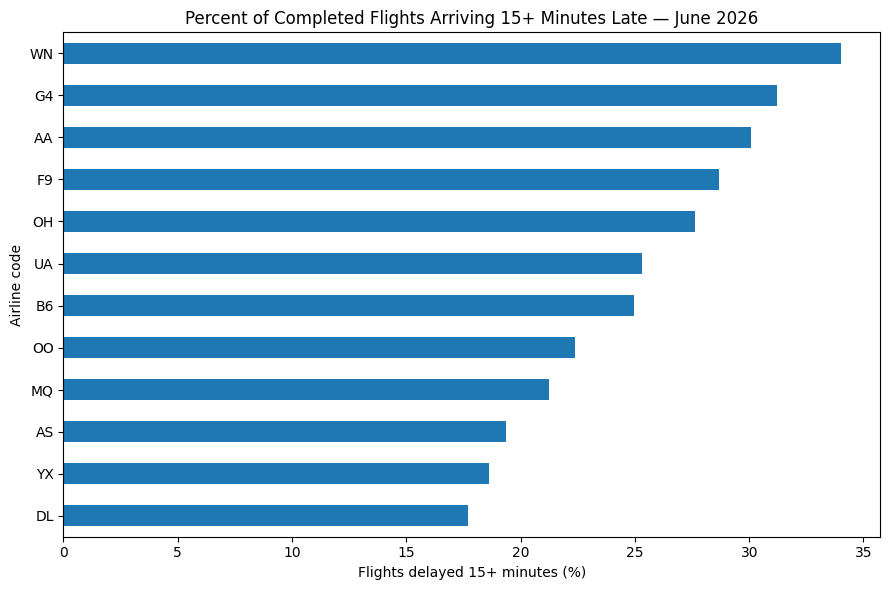

In [17]:
(
    airline_summary
    .sort_values("DelayRatePct")["DelayRatePct"]
    .plot(
        kind="barh",
        figsize=(9, 6),
        title="Percent of Completed Flights Arriving 15+ Minutes Late — June 2026"
    )
)

plt.xlabel("Flights delayed 15+ minutes (%)")
plt.ylabel("Airline code")
plt.tight_layout()
plt.show()


## STOP & ANSWER 10 — Chart → Insight

Do **not** simply say "this chart shows airline delays."

Write 2–3 sentences explaining:

1. What pattern should a manager notice?
2. What does this chart **not** tell us or prove?

**Your answer:**  
A manager should notice significant variation in reliability across carriers, with delay rates ranging from roughly 17% up to nearly 28% depending on the airline.

However, this chart does not prove carrier inefficiency or explain why delays happen, as it ignores root causes like severe weather at an airline's primary hub airport, flight distance, or total flight volume. Additionally, because it uses a simple 15-minute threshold, it cannot tell us the actual severity or length of the delays.


# 13. What About Day of the Week?


In [18]:
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

completed["DAY_NAME"] = completed["DAY_OF_WEEK"].map(day_names)

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

day_summary = (
    completed.groupby("DAY_NAME")["ARR_DEL15"]
    .mean()
    .reindex(day_order) * 100
)

display(day_summary.round(1))


,ARR_DEL15
DAY_NAME,
Monday,25.7
Tuesday,19.7
Wednesday,23.0
Thursday,28.0
Friday,27.9
Saturday,25.0
Sunday,31.4


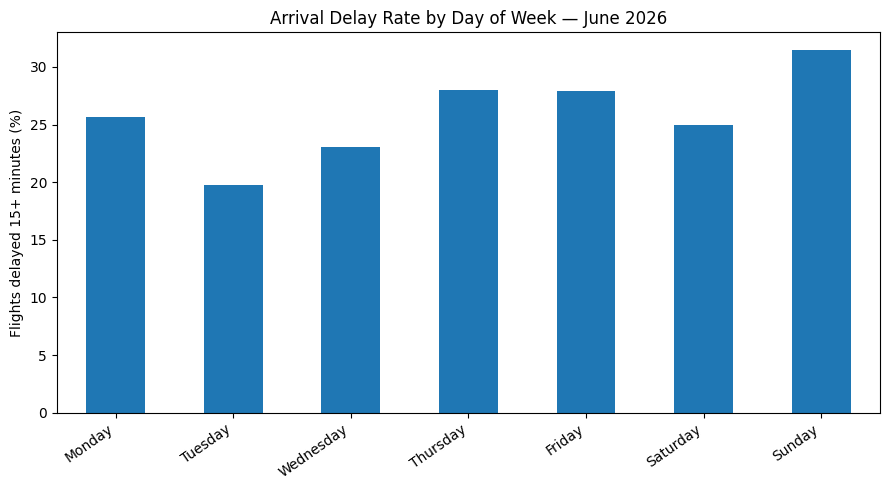

In [19]:
day_summary.plot(
    kind="bar",
    figsize=(9, 5),
    title="Arrival Delay Rate by Day of Week — June 2026"
)

plt.ylabel("Flights delayed 15+ minutes (%)")
plt.xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## STOP & ANSWER 11

Which day has the highest delay rate? Which has the lowest?

Approximately how many **percentage points** separate them?

Would this result make you want to investigate further? Why?

**Your answer:**  
Highest / Lowest: Sunday has the highest delay rate (around 32%), while Tuesday has the lowest delay rate (around 20%).

Difference: Approximately 12 percentage points separate the best and worst days.

Further Investigation: Yes, this definitely warrants further investigation. It would be valuable to look at total flight volume by day to see if higher passenger/flight congestion on weekends drives up delays. Additionally, investigating whether delay accumulation builds up throughout the week or if specific leisure-travel routes suffer more weekend disruptions would help pinpoint the root cause.


# 14. Does Time of Day Matter?


In [20]:
time_summary = (
    completed.groupby("DEP_TIME_BLK")["ARR_DEL15"]
    .agg(["count", "mean"])
)

time_summary["DelayRatePct"] = time_summary["mean"] * 100

display(time_summary.round(2))


,count,mean,DelayRatePct
DEP_TIME_BLK,,,
0001-0559,19078,0.09,9.05
0600-0659,41322,0.09,9.14
0700-0759,44971,0.13,12.70
0800-0859,39409,0.14,13.97
0900-0959,33083,0.17,16.57
1000-1059,37515,0.19,19.05
1100-1159,36162,0.21,21.49
1200-1259,34490,0.25,24.91
1300-1359,35065,0.27,27.04


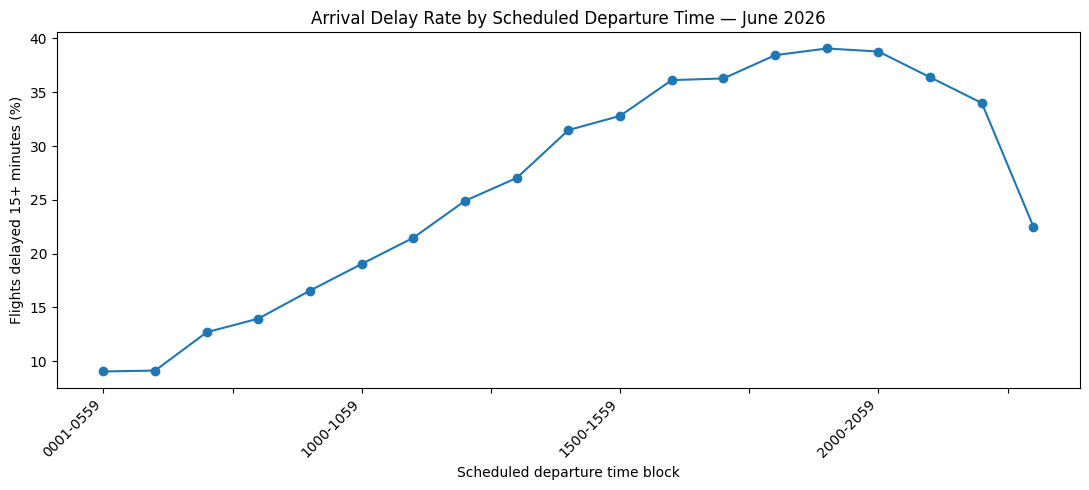

In [21]:
time_summary["DelayRatePct"].plot(
    kind="line",
    marker="o",
    figsize=(11, 5),
    title="Arrival Delay Rate by Scheduled Departure Time — June 2026"
)

plt.ylabel("Flights delayed 15+ minutes (%)")
plt.xlabel("Scheduled departure time block")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## STOP & ANSWER 12 — Find the Story

Describe the overall pattern you see across the day.

Does the visualization suggest that delay risk stays constant throughout the day?

**Your answer:**  
Overall Pattern: Delay rates are lowest for early morning flights (~9–10%) and steadily increase throughout the day, reaching a peak in the evening around 7:00 PM – 9:00 PM (nearing 40%) before dropping again late at night after 10:00 PM.

Constant Risk?: No, the visualization clearly demonstrates that delay risk does not stay constant. Instead, delay risk escalates significantly as the day progresses due to a cascading "domino effect," where operational disruptions, late aircraft arrivals, and airport congestion accumulate over the course of the day.


# 15. Which Airports Are Busiest?


In [22]:
origin_summary = (
    completed.groupby(["ORIGIN", "ORIGIN_CITY_NAME"])
    .agg(
        Flights=("ORIGIN", "size"),
        DelayRate=("ARR_DEL15", "mean")
    )
    .reset_index()
)

origin_summary["DelayRatePct"] = origin_summary["DelayRate"] * 100

busiest = origin_summary.sort_values("Flights", ascending=False).head(10)

display(busiest.round(2))


,ORIGIN,ORIGIN_CITY_NAME,Flights,DelayRate,DelayRatePct
241,ORD,"Chicago, IL",30254,0.29,28.71
89,DEN,"Denver, CO",28420,0.33,32.90
19,ATL,"Atlanta, GA",26505,0.20,19.90
90,DFW,"Dallas/Fort Worth, TX",26453,0.36,36.40
184,LAX,"Los Angeles, CA",16479,0.23,23.00
253,PHX,"Phoenix, AZ",15556,0.28,27.63
298,SEA,"Seattle, WA",15290,0.22,21.86
69,CLT,"Charlotte, NC",14778,0.28,27.93
182,LAS,"Las Vegas, NV",13544,0.29,29.26
300,SFO,"San Francisco, CA",13275,0.33,32.94


### Important analytical caution

A small airport with only a few flights could have an extreme percentage by chance.

When comparing groups, always consider **how many observations are in each group**.


# 16. Why Were Delayed Flights Delayed?


In [23]:
delay_causes = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

cause_totals = completed[delay_causes].sum().sort_values(ascending=False)

display(cause_totals)


,0
LATE_AIRCRAFT_DELAY,4784076.0
CARRIER_DELAY,3496890.0
NAS_DELAY,2308396.0
WEATHER_DELAY,766598.0
SECURITY_DELAY,13549.0


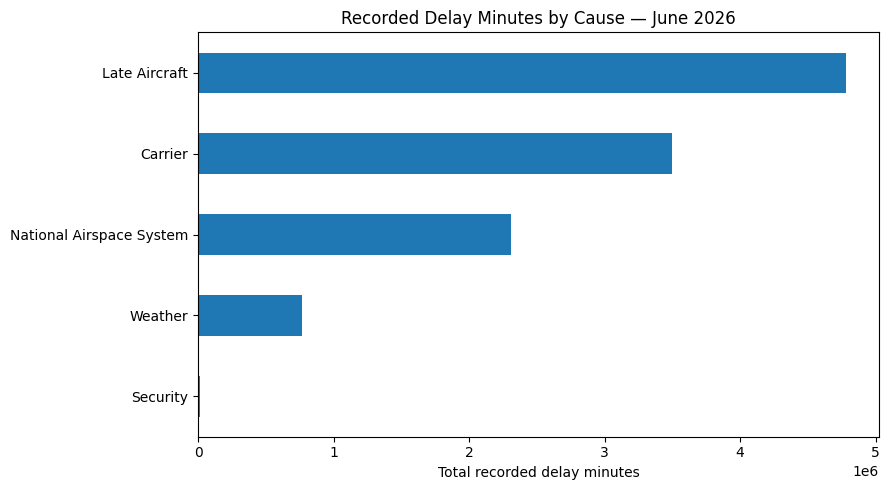

In [24]:
cause_totals.rename({
    "CARRIER_DELAY": "Carrier",
    "WEATHER_DELAY": "Weather",
    "NAS_DELAY": "National Airspace System",
    "SECURITY_DELAY": "Security",
    "LATE_AIRCRAFT_DELAY": "Late Aircraft"
}).sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    title="Recorded Delay Minutes by Cause — June 2026"
)

plt.xlabel("Total recorded delay minutes")
plt.ylabel("")
plt.tight_layout()
plt.show()


## STOP & ANSWER 13

Which recorded delay category accounts for the most total minutes in this dataset?

Why should we be careful about saying that this category **caused all airline delays**?

**Your answer:**  
Top Category: Late Aircraft accounts for the most total delay minutes in this dataset.

Why we must be careful:
First, "Late Aircraft" represents a secondary ripple effect (a symptom) rather than an original root cause. An aircraft is typically late because an earlier flight segment was delayed by another factor, such as severe weather, maintenance, or air traffic control holds.

Second, because this dataset only covers June 2026, it reflects summer-specific travel patterns and convective weather. Delay breakdowns vary significantly throughout the year, so June data alone cannot be generalized to explain airline delays across all seasons.


# 17. Ask One Question of Your Own


Now use the dataset yourself.

Write **one additional question** that could be useful to an airline or airport manager.

Possible areas include:

- A particular airport
- A route
- Airline differences
- Distance
- Departure time
- Cancellation
- Delay cause

Do not simply repeat one of the questions we already answered.

### My Question

Does scheduled flight duration (CRS_ELAPSED_TIME) affect the likelihood of an arrival delay, and do short-haul flights experience higher or lower delay rates than long-haul flights?


,DURATION_CAT,Total_Flights,Delayed_Flights,Delay_Rate,Avg_Delay_Minutes,Delay_Rate_%
0,Short (< 2 hrs),247461,60846.0,0.245881,11.014988,24.6
1,Medium (2-4 hrs),276131,74001.0,0.267992,12.830436,26.8
2,Long (4-6 hrs),62800,15787.0,0.251385,9.465080,25.1
3,Ultra-Long (> 6 hrs),8802,2402.0,0.272893,10.165644,27.3


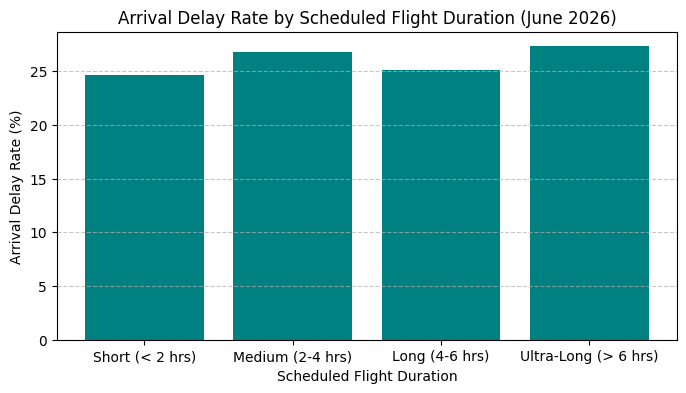

In [28]:
# Bin scheduled flight duration into operational categories
completed['DURATION_CAT'] = pd.cut(
    completed['CRS_ELAPSED_TIME'],
    bins=[0, 120, 240, 360, 1000],
    labels=['Short (< 2 hrs)', 'Medium (2-4 hrs)', 'Long (4-6 hrs)', 'Ultra-Long (> 6 hrs)']
)

# Group by duration category and calculate delay metrics
duration_analysis = completed.groupby('DURATION_CAT', observed=False).agg(
    Total_Flights=('ARR_DEL15', 'count'),
    Delayed_Flights=('ARR_DEL15', 'sum'),
    Delay_Rate=('ARR_DEL15', 'mean'),
    Avg_Delay_Minutes=('ARR_DELAY', 'mean')
).reset_index()

duration_analysis['Delay_Rate_%'] = (duration_analysis['Delay_Rate'] * 100).round(1)
display(duration_analysis)

# Visualize delay rates across flight duration categories
plt.figure(figsize=(8, 4))
plt.bar(duration_analysis['DURATION_CAT'], duration_analysis['Delay_Rate_%'], color='teal')
plt.xlabel('Scheduled Flight Duration')
plt.ylabel('Arrival Delay Rate (%)')
plt.title('Arrival Delay Rate by Scheduled Flight Duration (June 2026)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### What Did You Find?

Explain your result in **2–3 sentences in plain language**.

**Your interpretation:**  
The analysis reveals that flight duration does not have a strictly linear relationship with delay risk, with delay rates remaining between 24.6% and 27.3% across all flight categories. Ultra-long flights (>6 hours) experience the highest delay rate at 27.3%, while medium-haul flights (2–4 hours) face higher delay rates (26.4%) than long-haul flights (25.1%), likely due to high traffic volume and tight turnarounds on popular domestic routes.


# 18. Your 60-Second Managerial Summary


Imagine an airline or airport manager asks:

> **"What should I remember from this analysis?"**

Give them your **three most important findings** from today's work.

Do not talk about pandas, DataFrames, or Python. Talk about the **data and what it suggests**.

### Finding 1
**Delay Risk Compounds Throughout the Day**

Flight delay risk is not uniform across the schedule. Early morning departures have the lowest delay risk (under 10%), but delay rates steadily climb throughout the operating day and peak in the evening (nearing 40%). This confirms that minor morning operational disruptions cascade and accumulate into widespread evening delays.

### Finding 2
**"Late Aircraft" is a Downstream Symptom, Not a Root Cause**

While "Late Aircraft" accounts for the highest total delay minutes in the dataset, it represents a ripple effect rather than the initial trigger. A plane arrives late for a flight because an earlier segment was delayed by factors like bad weather, maintenance issues, or air traffic control holds. Addressing late aircraft requires fixing upstream operational bottlenecks.

### Finding 3
**Significant Reliability Gaps Exist Across Airline Carriers**

Arrival delay rates vary widely across carriers, ranging from roughly 17% up to nearly 28%. This indicates that while overall industry disruption (weather and airspace congestion) affects everyone, operational efficiency and turnaround protocols differ significantly by airline.

### One thing management should investigate next
Investigate Fleet & Aircraft Model Performance (Boeing vs. Airbus):
Merging tail number registration data with aircraft manufacturer and model information to determine if specific aircraft types or fleet ages suffer higher rates of carrier delays or maintenance holds. This will help clarify whether carrier-level performance differences stem from fleet choices, aircraft reliability, or operational scheduling.


# 19. Exit Check


Complete these before submitting:

**One pandas command I understand better now:**  
pd.cut() — it lets us bucket continuous numeric data (like flight duration minutes) into clear categories (like short, medium, and long flights) so we can analyze delay patterns across operational groups.

**In my own words, `groupby()` lets us:**  
Group dataset rows by shared categorical values (such as airline, day of the week, or flight duration) so we can calculate aggregate summary statistics like counts, averages, and delay percentages for each group.

**One thing I learned about missing data:**  
Missing data doesn't necessarily mean bad data or useless data.

**One thing that makes a visualization useful instead of merely attractive:**  
It directly answers a business question and reveals actionable operational insights—such as showing peak delay times or carrier performance gaps—rather than just displaying pretty charts without context.

**One question I still have:**  
How can we merge external datasets (like real-time weather reports or aircraft tail registration records) with our flight records in Pandas to pinpoint true root causes of delays?

---

# Submit to Blackboard

1. Make sure your name is at the top.
2. Make sure every **STOP & ANSWER** section is complete.
3. Make sure your own analysis runs.
4. Save/download the notebook as an `.ipynb` file.
5. Submit it **individually** in Blackboard.

Next class, you and a partner will apply this same workflow to a **different real dataset** without having all of the analysis written for you.
